In [ ]:
import pandas as pd
import datetime
from datetime import date, timedelta
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amirmotefaker/ab-testing-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.07k/2.07k [00:00<00:00, 1.87MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/amirmotefaker/ab-testing-dataset/versions/1


In [ ]:
# Suppose your CSV file path is:
csv_path = f"{path}/control_group.csv"

# Read into pandas
control_data = pd.read_csv(f"{path}/control_group.csv", sep = ";")
test_data = pd.read_csv(f"{path}/test_group.csv", sep = ";")
print(control_data.head())
print('-' * 100)
print(test_data.head())

      Campaign Name       Date  Spend [USD]  # of Impressions     Reach  \
0  Control Campaign  1.08.2019         2280           82702.0   56930.0   
1  Control Campaign  2.08.2019         1757          121040.0  102513.0   
2  Control Campaign  3.08.2019         2343          131711.0  110862.0   
3  Control Campaign  4.08.2019         1940           72878.0   61235.0   
4  Control Campaign  5.08.2019         1835               NaN       NaN   

   # of Website Clicks  # of Searches  # of View Content  # of Add to Cart  \
0               7016.0         2290.0             2159.0            1819.0   
1               8110.0         2033.0             1841.0            1219.0   
2               6508.0         1737.0             1549.0            1134.0   
3               3065.0         1042.0              982.0            1183.0   
4                  NaN            NaN                NaN               NaN   

   # of Purchase  
0          618.0  
1          511.0  
2          372.0  
3   

#Data Cleaning

In [ ]:
control_data.columns = ["campaign", "date", "spend",
                        "impressions", "reach", "clicks",
                        "searches", "views", "add_to_cart",
                        "purchases"]

test_data.columns = ["campaign", "date", "spend",
                        "impressions", "reach", "clicks",
                        "searches", "views", "add_to_cart",
                        "purchases"]


In [ ]:
null_rows = control_data[control_data.isnull().any(axis=1)]
null_row_indices = control_data[control_data.isnull().any(axis=1)].index

print("Rows with missing values:")
print(null_rows)
print("\nRow indices with missing values:", null_row_indices.tolist())

Rows with missing values:
           campaign       date  spend  impressions  reach  clicks  searches  \
4  Control Campaign  5.08.2019   1835          NaN    NaN     NaN       NaN   

   views  add_to_cart  purchases  
4    NaN          NaN        NaN  

Row indices with missing values: [4]


In [ ]:
null_rows = test_data[test_data.isnull().any(axis=1)]
null_row_indices = test_data[test_data.isnull().any(axis=1)].index

print("Rows with missing values:")
print(null_rows)
print("\nRow indices with missing values:", null_row_indices.tolist())

Rows with missing values:
Empty DataFrame
Columns: [campaign, date, spend, impressions, reach, clicks, searches, views, add_to_cart, purchases]
Index: []

Row indices with missing values: []


In [ ]:
control_data = control_data.dropna()
print("\nShape of control_data after dropping missing values:", control_data.shape)


Shape of control_data after dropping missing values: (29, 10)


In [ ]:
print(test_data.isnull().sum())

campaign       0
date           0
spend          0
impressions    0
reach          0
clicks         0
searches       0
views          0
add_to_cart    0
purchases      0
dtype: int64


#Metrics Selection & Creation




In [ ]:
def metrics_data(data):
    data = data.copy()
    data['CTR'] = data['clicks'] / data['impressions']
    data['CTR'] = data['CTR'].replace([np.inf, -np.inf], np.nan).fillna(data['CTR'].mean())
    return data

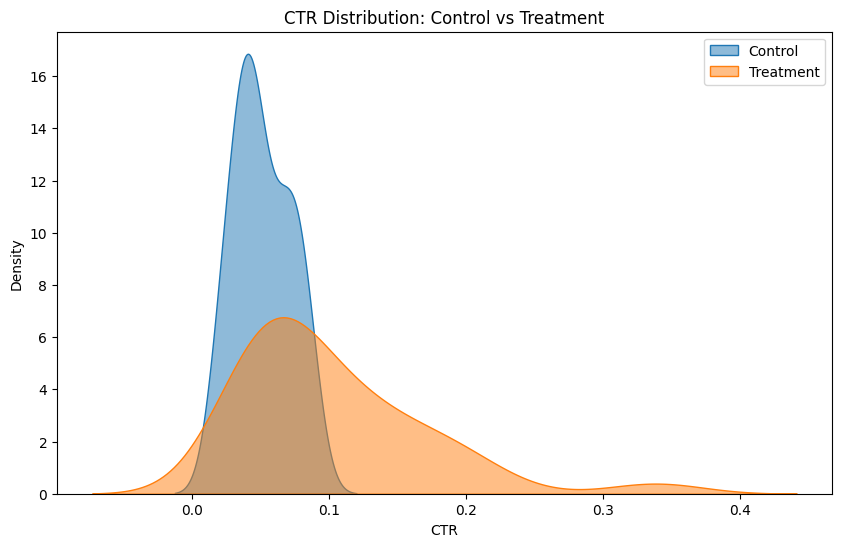

In [ ]:
# Apply to both control and treatment
control = metrics_data(control_data)
treatment = metrics_data(test_data)

# Plot distribution of CTR
plt.figure(figsize=(10,6))
sns.kdeplot(control['CTR'], label='Control', fill=True, alpha=0.5)
sns.kdeplot(treatment['CTR'], label='Treatment', fill=True, alpha=0.5)
plt.title('CTR Distribution: Control vs Treatment')
plt.xlabel('CTR')
plt.ylabel('Density')
plt.legend()
plt.show()

#Observations

Control group (blue)

- CTR is mostly concentrated around 0.05–0.1.

- Distribution is narrow and peaked, meaning most control users have similar CTR values.

Treatment group (orange)

- CTR distribution is shifted to the right, with a longer tail toward 0.2–0.4.

- This suggests that some users in the treatment group are clicking much more often, but there’s also more variability.

Overlap

- There is some overlap around, meaning a portion of treatment users behaves similarly to control users.

- But the overall distribution of treatment is higher, hinting at a positive effect.

# Power Analysis

In [ ]:
from statsmodels.stats.power import TTestIndPower

# Extract CTR series
ctr_control = control['CTR']
ctr_treatment = treatment['CTR']

# Compute means and standard deviations
mean_control = ctr_control.mean()
mean_treatment = ctr_treatment.mean()
std_control = ctr_control.std(ddof=1)
std_treatment = ctr_treatment.std(ddof=1)

# Pooled standard deviation
pooled_std = np.sqrt((std_control**2 + std_treatment**2) / 2)

# Effect size (Cohen's d)
effect_size = (mean_treatment - mean_control) / pooled_std
print(f"Effect size (Cohen's d): {effect_size:.3f}")

# Power analysis
alpha = 0.05  # significance level
power = 0.8   # desired power

analysis = TTestIndPower()
sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')
print(f"Required sample size per group: {np.ceil(sample_size)}")


Effect size (Cohen's d): 1.029
Required sample size per group: 16.0


## Power Analysis for CTR Experiment

Objective: Estimate the required sample size to detect a difference in CTR between control and treatment groups.

Method:

Compute CTR for each group, handling NaNs and infinities.

Calculate means and standard deviations.

Compute Cohen’s d (effect size).

Use TTestIndPower to calculate the sample size needed for 80% power at a 5% significance level.

Results:

Effect size (Cohen’s d): 1.029 → large effect.

Required sample size per group: 16

Interpretation: The treatment has a strong impact on CTR. With 16 or more users per group, the experiment has a high chance of detecting this effect statistically.

In [ ]:
print(control.shape)
print('-' * 10)
print(treatment.shape)

(29, 11)
----------
(30, 11)


Seems like we do have enough sample size for this experimentation

In [ ]:
sampled_control = control['CTR']
sampled_treatment = treatment['CTR']

# Sharpiro Test for Normality

In [ ]:
from scipy import stats

# Sampled CTRs
data_t = sampled_treatment
data_c = sampled_control

# Shapiro-Wilk normality test for treatment
stat_t, p_t = stats.shapiro(data_t)
print(f"Treatment - Shapiro-Wilk statistic: {stat_t:.3f}, p-value: {p_t:.3f}")
if p_t > 0.05:
    print("Treatment data looks normally distributed (fail to reject H0).")
else:
    print("Treatment data is not normally distributed (reject H0).")

# Shapiro-Wilk normality test for control
stat_c, p_c = stats.shapiro(data_c)
print(f"Control - Shapiro-Wilk statistic: {stat_c:.3f}, p-value: {p_c:.3f}")
if p_c > 0.05:
    print("Control data looks normally distributed (fail to reject H0).")
else:
    print("Control data is not normally distributed (reject H0).")


Treatment - Shapiro-Wilk statistic: 0.841, p-value: 0.000
Treatment data is not normally distributed (reject H0).
Control - Shapiro-Wilk statistic: 0.955, p-value: 0.245
Control data looks normally distributed (fail to reject H0).


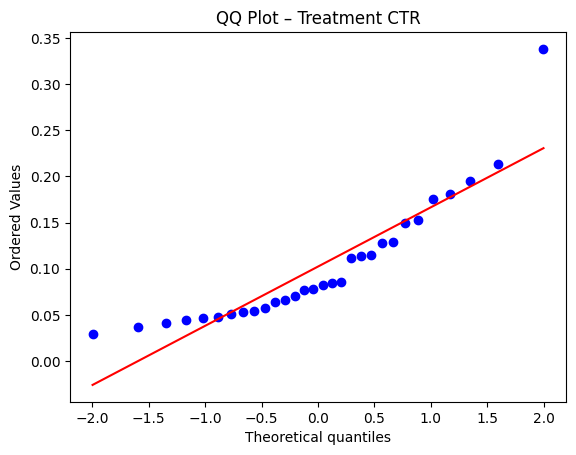

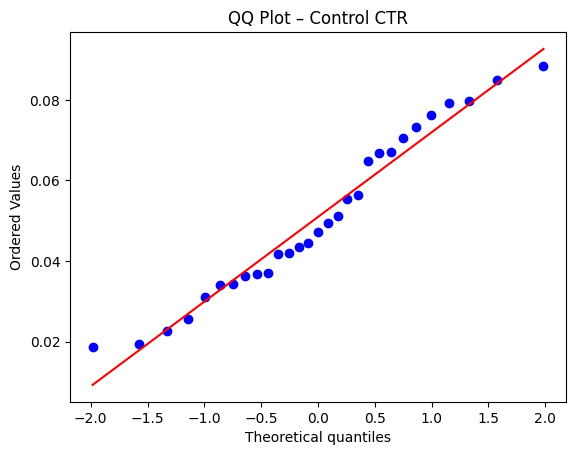

In [ ]:
from scipy import stats

# Visual Sanity Check

# QQ plot for Treatment
plt.figure()
stats.probplot(data_t, dist="norm", plot=plt)
plt.title("QQ Plot – Treatment CTR")
plt.show()

# QQ plot for Control
plt.figure()
stats.probplot(data_c, dist="norm", plot=plt)
plt.title("QQ Plot – Control CTR")
plt.show()


In [ ]:
from scipy import stats

# Sampled CTRs
data_t = sampled_treatment
data_c = sampled_control

# Levene's test for equal variances
stat_levene, p_levene = stats.levene(data_t, data_c)
print(f"Levene's statistic: {stat_levene:.3f}, p-value: {p_levene:.3f}")

if p_levene > 0.05:
    print("Variances are similar (fail to reject H0).")
else:
    print("Variances are different (reject H0). Consider using Welch's t-test or a non-parametric test.")


Levene's statistic: 9.708, p-value: 0.003
Variances are different (reject H0). Consider using Welch's t-test or a non-parametric test.


# Levene Test for constant variance

In [ ]:
from scipy.stats import levene

stat, p_value = levene(sampled_control, sampled_treatment)
print(f"Levene test statistic: {stat:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpretation
if p_value > 0.05:
    print("Fail to reject H0: variances are roughly equal. You can use Student's t-test.")
else:
    print("Reject H0: variances are different. Use Welch's t-test instead.")


Levene test statistic: 9.708
P-value: 0.003
Reject H0: variances are different. Use Welch's t-test instead.


# Mann-Whitney U Test


In [ ]:
import numpy as np
from scipy import stats

control_data = sampled_control
treatment_data = sampled_treatment

# Mann-Whitney U test
u_stat, p_value = stats.mannwhitneyu(treatment_data, control_data, alternative='two-sided')

# Calculate effect size r
n1 = len(treatment_data)
n2 = len(control_data)
# Approximate Z from U
mean_U = n1 * n2 / 2
std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
z = (u_stat - mean_U) / std_U
r = z / np.sqrt(n1 + n2)

print(f"Mann-Whitney U statistic: {u_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"Effect size r: {r:.3f}")

# Interpretation
if abs(r) < 0.1:
    magnitude = "negligible"
elif abs(r) < 0.3:
    magnitude = "small"
elif abs(r) < 0.5:
    magnitude = "medium"
else:
    magnitude = "large"

print(f"Effect size magnitude: {magnitude}")


Mann-Whitney U statistic: 677.000
P-value: 0.000
Effect size r: 0.478
Effect size magnitude: medium


In [ ]:
import numpy as np

control_data = sampled_control.values  # convert to numpy array if not already
treatment_data = sampled_treatment.values

# Number of bootstrap samples
n_boot = 100000
diffs = []

for _ in range(n_boot):
    sample_control = np.random.choice(control_data, size=len(control_data), replace=True)
    sample_treatment = np.random.choice(treatment_data, size=len(treatment_data), replace=True)
    diffs.append(np.median(sample_treatment) - np.median(sample_control))

# 95% CI
ci_low = np.percentile(diffs, 2.5)
ci_high = np.percentile(diffs, 97.5)
median_diff = np.median(treatment_data) - np.median(control_data)

print(f"Median difference: {median_diff:.3f}")
print(f"95% CI for median difference: ({ci_low:.3f}, {ci_high:.3f})")


Median difference: 0.033
95% CI for median difference: (0.009, 0.071)


All in all, the test itself suggest that the the treatment group have a positive effect over control group.

Expected CTR uplift with Confidence Interval is 0.9% to 7.1% with a median of 3.3%, which aligns with the low p-value as it doesn't contain any 0 values.

Final Decision at least for CTR is to release the treatment group feature slowly to 10-20% of our user base, with guardrail metrics such as retention rate